In [58]:
### import necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [59]:
### import data

data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")

In [ ]:
### feature selection

# list of featires to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "Overall Survival (Months)",
              "Patient's Vital Status",
              "Relapse Free Status (Months)",
              "Relapse Free Status"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'Overall Survival (Months)',
       'Patient's Vital Status', 'Relapse Free Status (Months)',
       'Relapse Free Status'],
      dtype='str')


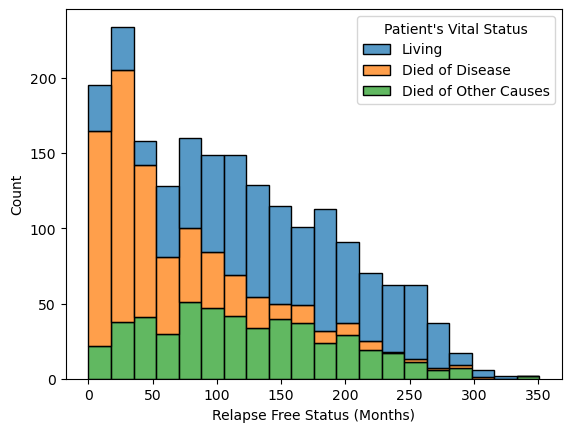

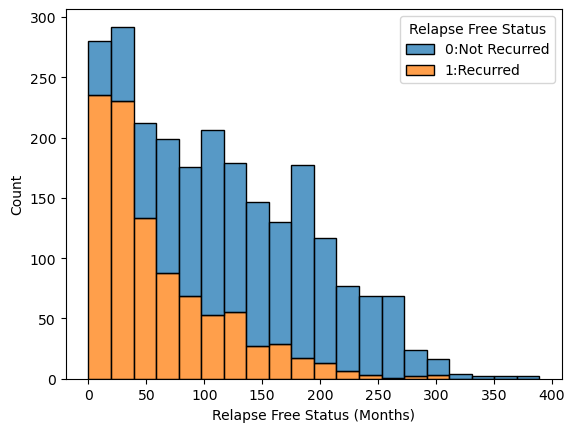

Relapse Free Status (Months)
28.000000     5
192.000000    5
102.000000    4
32.533333     4
0.000000      4
             ..
55.633333     1
73.733333     1
63.266667     1
5.000000      1
16.400000     1
Name: count, Length: 1972, dtype: int64
21
121


In [37]:
sns.histplot(
    data=data,
    x="Relapse Free Status (Months)",
    hue="Patient's Vital Status",  # replace with your actual column name
    bins=20,
    multiple="stack"  # options: "stack", "layer", "dodge", "fill"
)
plt.show()

sns.histplot(
    data=data,
    x="Relapse Free Status (Months)",
    hue="Relapse Free Status",  # replace with your actual column name
    bins=20,
    multiple="stack"  # options: "stack", "layer", "dodge", "fill"
)
plt.show()

print(data["Relapse Free Status (Months)"].value_counts())
print(data["Relapse Free Status"].isna().sum())
print(data["Relapse Free Status (Months)"].isna().sum())

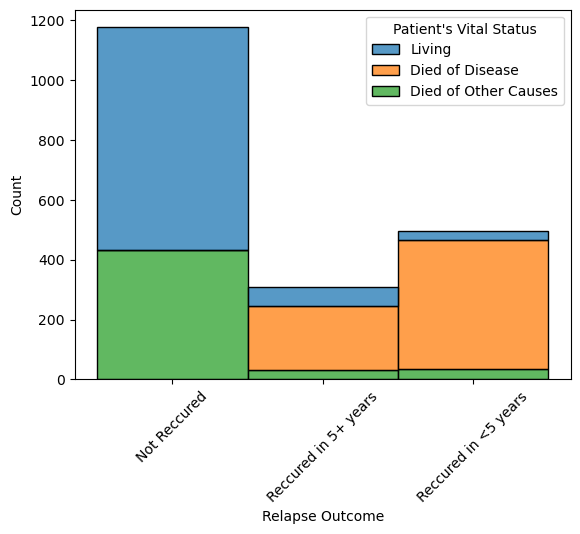

In [61]:
for index, row in data.iterrows():
    if row["Relapse Free Status"]== "0:Not Recurred":
        data.loc[index, "Relapse Outcome"] = "Not Reccured"
    elif row["Relapse Free Status (Months)"]<60:
        data.loc[index, "Relapse Outcome"] = "Reccured in <5 years"
    elif row["Relapse Free Status (Months)"]>=60:
        data.loc[index, "Relapse Outcome"] = "Reccured in 5+ years"
    
sns.histplot(
    data=data,
    x="Relapse Outcome",
    hue="Patient's Vital Status",  # replace with your actual column name
    bins=20,
    multiple="stack"  # options: "stack", "layer", "dodge", "fill"
)
plt.xticks(rotation=45)
plt.show()

data = data.dropna(subset=["Relapse Outcome"])

In [62]:
### group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1841
Breast Mixed Ductal and Lobular Carcinoma     268
Breast Invasive Lobular Carcinoma             188
Other                                         161
Name: count, dtype: int64


In [63]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster"]

x= data[predictors]
y=data["Relapse Outcome"]

In [64]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42)

In [65]:
### impute missing predictor values

# check NaNs
print(x_train.isna().sum())
print(x_test.isna().sum())

# impute menopausal status based on age
mask = x_test["Inferred Menopausal State"].isna()
x_test.loc[mask, "Inferred Menopausal State"] = np.where(
    x_test.loc[mask, "Age at Diagnosis"] < 52,
    "Pre",
    "Post")

# impute tumor size from training median
tumor_size_median = x_train["Tumor Size"].median()
x_train["Tumor Size"] = x_train["Tumor Size"].fillna(tumor_size_median)
x_test["Tumor Size"] = x_test["Tumor Size"].fillna(tumor_size_median)

# impute lymph nodes from training median
lymph_node_median = x_train["Lymph nodes examined positive"].median()
x_train["Lymph nodes examined positive"] = x_train["Lymph nodes examined positive"].fillna(lymph_node_median)
x_test["Lymph nodes examined positive"] = x_test["Lymph nodes examined positive"].fillna(lymph_node_median)

# impute 3-gene classifier using training mode
three_gene_mode = x_train["3-Gene classifier subtype"].mode()[0]
x_train["3-Gene classifier subtype"] = x_train["3-Gene classifier subtype"].fillna(three_gene_mode)
x_test["3-Gene classifier subtype"] = x_test["3-Gene classifier subtype"].fillna(three_gene_mode)

# impute Pam50 using training mode
pam50_mode = x_train["Pam50 + Claudin-low subtype"].mode()[0]
x_train["Pam50 + Claudin-low subtype"] = x_train["Pam50 + Claudin-low subtype"].fillna(pam50_mode)
x_test["Pam50 + Claudin-low subtype"] = x_test["Pam50 + Claudin-low subtype"].fillna(pam50_mode)

# impute IntCluster using training mode
int_cluster_mode = x_train["Integrative Cluster"].mode()[0]
x_train["Integrative Cluster"] = x_train["Integrative Cluster"].fillna(int_cluster_mode)
x_test["Integrative Cluster"] = x_test["Integrative Cluster"].fillna(int_cluster_mode)


# confirm NaNs are removed
print(x_train.isna().sum())
print(x_test.isna().sum())

Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State        365
Tumor Size                        80
Lymph nodes examined positive    171
3-Gene classifier subtype        534
Pam50 + Claudin-low subtype      365
Integrative Cluster              365
dtype: int64
Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State        113
Tumor Size                        23
Lymph nodes examined positive     60
3-Gene classifier subtype        160
Pam50 + Claudin-low subtype      113
Integrative Cluster              113
dtype: int64
Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State        365
Tumor Size                         0
Lymph nodes examined positive      0
3-Gene classifier subtype          0
Pam50 + Claudin-low subtype        0
Integrative Cluster                0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inf

In [66]:
### seperate x train and x test for each model

# model 1- baseline
x1=["Age at Diagnosis", 
    "Cancer Type Grouped", 
    "Inferred Menopausal State", 
    "Tumor Size",
    "Lymph nodes examined positive"]
x1_train= x_train[x1]
x1_test= x_test[x1]

# model 2- baseline + 3-gene
x2= x1 + ["3-Gene classifier subtype"]
x2_train= x_train[x2]
x2_test= x_test[x2]

# model 3- baseline + Pam 50
x3= x1 + ["Pam50 + Claudin-low subtype"]
x3_train= x_train[x3]
x3_test= x_test[x3]

# model 4 - baseline + integrative clusters
x4= x1 + ["Integrative Cluster"]
x4_train= x_train[x4]
x4_test= x_test[x4]



In [67]:
# Remove NC (not classified) from X3
# Training set
mask_train = x3_train["Pam50 + Claudin-low subtype"] != "NC"
x3_train = x3_train[mask_train]
y3_train = y_train[mask_train]

# Test set
mask_test = x3_test["Pam50 + Claudin-low subtype"] != "NC"
x3_test = x3_test[mask_test]
y3_test = y_test[mask_test]

In [68]:
### One hot encode

x1_train = pd.get_dummies(x1_train)
x1_test = pd.get_dummies(x1_test)

x2_train = pd.get_dummies(x2_train)
x2_test = pd.get_dummies(x2_test)

x3_train = pd.get_dummies(x3_train)
x3_test = pd.get_dummies(x3_test)

x4_train = pd.get_dummies(x4_train)
x4_test = pd.get_dummies(x4_test)

In [69]:
### establish RandomForest models

# model 1
rf1 = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

# model 2
rf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

# model 3
rf3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

# model 4
rf4 = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

In [70]:
### fit models 

# model 1
rf1.fit(x1_train, y_train)

# model 2
rf2.fit(x2_train, y_train)

# model 3
rf3.fit(x3_train, y3_train)

# model 4
rf4.fit(x4_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [71]:
### make predictions

# model 1
y1_pred = rf1.predict(x1_test)

# model 2
y2_pred = rf2.predict(x2_test)

# model 3
y3_pred = rf3.predict(x3_test)

# model 4
y4_pred = rf4.predict(x4_test)

In [72]:
### evaluate models

# model 1
print("Accuracy:", accuracy_score(y_test, y1_pred))
print(classification_report(y_test, y1_pred))

# model 2
print("Accuracy:", accuracy_score(y_test, y2_pred))
print(classification_report(y_test, y2_pred))

# model 3
print("Accuracy:", accuracy_score(y_test, y3_pred))
print(classification_report(y_test, y3_pred))

# model 4
print("Accuracy:", accuracy_score(y_test, y4_pred))
print(classification_report(y_test, y4_pred))

Accuracy: 0.5365853658536586
                      precision    recall  f1-score   support

        Not Reccured       0.64      0.74      0.69       297
Reccured in 5+ years       0.07      0.04      0.05        74
Reccured in <5 years       0.38      0.33      0.35       121

            accuracy                           0.54       492
           macro avg       0.36      0.37      0.36       492
        weighted avg       0.49      0.54      0.51       492

Accuracy: 0.573170731707317
                      precision    recall  f1-score   support

        Not Reccured       0.65      0.80      0.72       297
Reccured in 5+ years       0.06      0.03      0.04        74
Reccured in <5 years       0.46      0.36      0.40       121

            accuracy                           0.57       492
           macro avg       0.39      0.39      0.38       492
        weighted avg       0.51      0.57      0.54       492

Accuracy: 0.5813008130081301
                      precision    recal

In [ ]:
### plot most important features

# model 1
importances1 = pd.Series(rf1.feature_importances_, index=x1_train.columns)
top_features1 = importances1.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features1.plot(kind="bar")
plt.title("Top Feature Importances - RF1")
plt.ylabel("Importance")
plt.show()

# model 2
importances2 = pd.Series(rf2.feature_importances_, index=x2_train.columns)
top_features2 = importances2.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features2.plot(kind="bar")
plt.title("Top Feature Importances - RF2")
plt.ylabel("Importance")
plt.show()

# model 3
importances3 = pd.Series(rf3.feature_importances_, index=x3_train.columns)
top_features3 = importances3.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features3.plot(kind="bar")
plt.title("Top Feature Importances - RF3")
plt.ylabel("Importance")
plt.show()

# model 4
importances4 = pd.Series(rf4.feature_importances_, index=x4_train.columns)
top_features4 = importances4.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features4.plot(kind="bar")
plt.title("Top Feature Importances - RF4")
plt.ylabel("Importance")
plt.show()